In [1]:
import warnings
warnings.filterwarnings('ignore')

import geopandas as gpd          # Geospatial data handling (GeoDataFrame, GeoSeries)
from shapely import geometry      # Geometry primitives (box, polygon)
import cartopy.crs as ccrs        # Coordinate reference systems for map projections
import matplotlib.pyplot as plt   # Plotting
import matplotlib.patches as patches  # Drawing shapes on plots (e.g., bounding box)

# Search SWOT Satellite Tracks

This notebook identifies SWOT (Surface Water and Ocean Topography) satellite half-orbit tracks that intersect a region of interest (ROI), defined by a bounding box.

## Workflow
1. Define a bounding box (longitude/latitude range) for the region of interest
2. Load SWOT KaRIn swath geometries from a local GeoJSON file
3. Filter half-orbit tracks that intersect the bounding box
4. Export the matching tracks to CSV
5. Visualize the intersecting swaths and individual half orbits

## Data
- **Swath geometry file**: `KaRIn_2kms_science_geometries.geojson` — polygon footprints for each SWOT half-orbit pass
- **Phase options**: `'science'` (nominal operations) or `'calval'` (calibration/validation)

## Helper Functions

In [2]:
def get_half_orbits_intersect(bbox):
    """Get half orbits that intersect a bounding box.

    Parameters
    ----------
    bbox: 
        the bounding box
        
    Returns
    -------
     gpd.GeoDataFrame:
        A Geopandas dataframe containing intersecting half orbits numbers and geometries
    """
    swath_geometries = gpd.read_file(GEOMETRIES_FILE)

    bbox_polygon = geometry.box(*bbox)

    def _filter_intersect(row, polygon):
        half_orbit_polygon = row.geometry
        return polygon.intersects(half_orbit_polygon)

    select = swath_geometries.apply(_filter_intersect, polygon=bbox_polygon, axis=1)
    return swath_geometries[select]

In [3]:
def plot_geometries(geometries, lon_range, lat_range, title, plot_extent=None):
    """Plot SWOT swath geometries on a map with the bounding box overlaid.

    Parameters
    ----------
    geometries : gpd.GeoDataFrame
        GeoDataFrame containing the swath polygon geometries to plot.
    lon_range : tuple of (float, float)
        (min_lon, max_lon) defining the bounding box longitude extent.
    lat_range : tuple of (float, float)
        (min_lat, max_lat) defining the bounding box latitude extent.
    title : str
        Plot title.
    plot_extent : list of [min_lon, max_lon, min_lat, max_lat], optional
        Cartopy map extent. If None, uses the full global extent.
    """
    fig, ax = plt.subplots(ncols=1, figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

    # Draw swath polygons in blue
    gpd.GeoSeries(geometries.geometry).plot(ax=ax, transform=ccrs.PlateCarree(), alpha=1)

    # Overlay the bounding box in orange for reference
    square = patches.Rectangle(
        (lon_range[0], lat_range[0]),
        lon_range[1] - lon_range[0],
        lat_range[1] - lat_range[0],
        edgecolor='orange', facecolor='none',
        transform=ccrs.PlateCarree()
    )
    ax.add_patch(square)

    ax.set_title(title)
    ax.coastlines()

    # Zoom into the region of interest if an extent is provided
    if plot_extent:
        ax.set_extent(plot_extent, crs=ccrs.PlateCarree())

---
## Example 1: Mekong River Basin

Define the bounding box covering the Mekong River Basin region (Southeast Asia) and find intersecting SWOT half-orbit tracks.


In [4]:
# Bounding box covering the Mekong/Ba River Watershed (Southeast Asia)
# Longitude: 89°E – 112°E  |  Latitude: 7°N – 34°N
lon_range = 89, 112
lat_range = 7, 34

In [5]:
# Build bounding box and map extent (same as Example 1)
bbox = [lon_range[0], lat_range[0], lon_range[1], lat_range[1]]
plot_extent = [lon_range[0], lon_range[1], lat_range[0], lat_range[1]]

In [ ]:
# Select SWOT mission phase ('science' or 'calval')
phase = 'science'
# SWOT science passes (21-day-repeat science orbit)
# Downloaded from URL: https://swot.jpl.nasa.gov/mission/swath-visualizer/

GEOMETRIES_FILE = r'E:\Project_2025_2026\Smart_hs\raw_data\swot\KaRIn_2kms_science_geometries.geojson'

In [ ]:
# Find all SWOT half-orbit tracks intersecting the Mekong/Ba River Watershed bounding box
swath_geoms = get_half_orbits_intersect(bbox)

In [ ]:
print('The SWOT passes that intersect the region of interest:')
print(swath_geoms['pass_number'].values)

The SWOT passes that intersect the region of interest:
[  6   8  21  34  49  62  77  90 105 118 133 146 161 174 189 202 215 217
 230 243 258 271 284 286 299 312 327 340 355 368 383 396 411 424 439 452
 467 480 493 495 508 521 523 536 549 562 564 577]


In [10]:
# Export intersecting swath geometries (pass numbers + polygons) to CSV for later use
# swath_geoms.to_csv(r"E:\Project_2025_2026\Smart_hs\raw_data\swot\mekong_river_basin\swot_passes.csv", index=False)

---
## Inspect Results

List the pass numbers of all intersecting SWOT half-orbit tracks.

In [14]:
# Extract and display the list of half-orbit pass numbers that intersect the region
half_orbits = list(swath_geoms['pass_number'])
print(f"Found {len(half_orbits)} intersecting half orbits:")
half_orbits

Found 48 intersecting half orbits:


[6,
 8,
 21,
 34,
 49,
 62,
 77,
 90,
 105,
 118,
 133,
 146,
 161,
 174,
 189,
 202,
 215,
 217,
 230,
 243,
 258,
 271,
 284,
 286,
 299,
 312,
 327,
 340,
 355,
 368,
 383,
 396,
 411,
 424,
 439,
 452,
 467,
 480,
 493,
 495,
 508,
 521,
 523,
 536,
 549,
 562,
 564,
 577]

---
## Visualize SWOT Swath Geometries

### All intersecting passes
Plot all half-orbit swaths that intersect the bounding box. The orange rectangle shows the bounding box (region of interest).

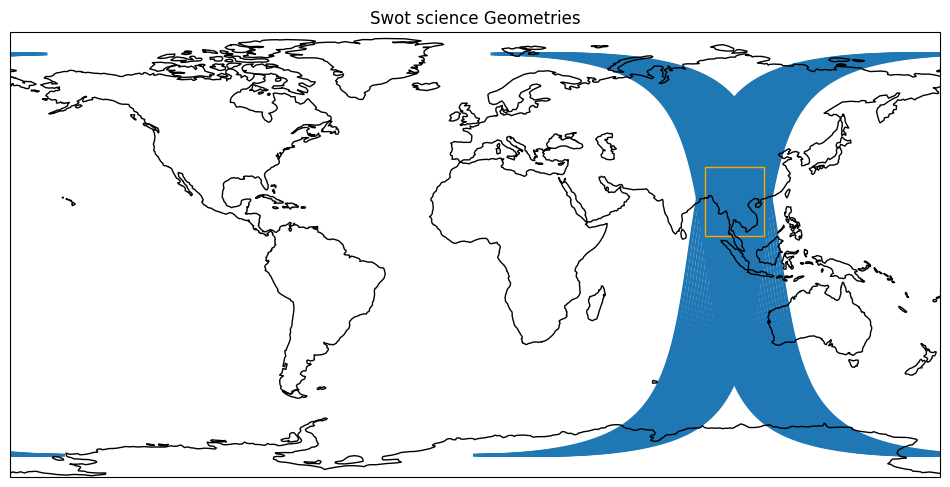

In [15]:
# Plot geometries
plot_geometries(swath_geoms, lon_range, lat_range, f"Swot {phase} Geometries")

### Individual half-orbit passes

Zoom in to the Mekong/Lower Mekong region and inspect specific half-orbit passes one at a time.
The cells below each plot a single pass identified by its `pass_number`.

In [16]:
# Zoom extent for the Lower Mekong / Vietnam region
# Longitude: 105°E – 112°E  |  Latitude: 8°N – 21°N
lon_range = (105, 112)
lat_range = (8, 21)
plot_extent = [lon_range[0], lon_range[1], lat_range[0], lat_range[1]]

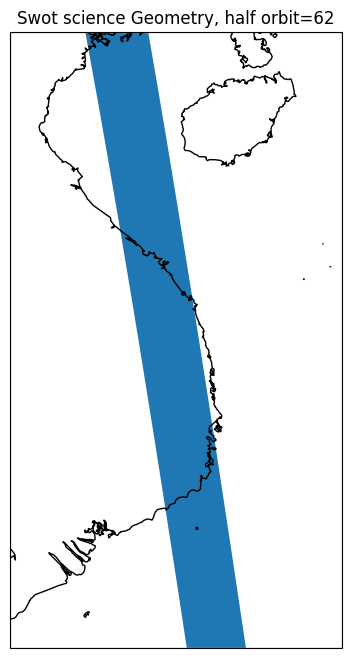

In [17]:
half_orbit_num = 62
plot_geometries(swath_geoms[swath_geoms['pass_number']==half_orbit_num], lon_range, lat_range, f"Swot {phase} Geometry, half orbit={half_orbit_num}", plot_extent)

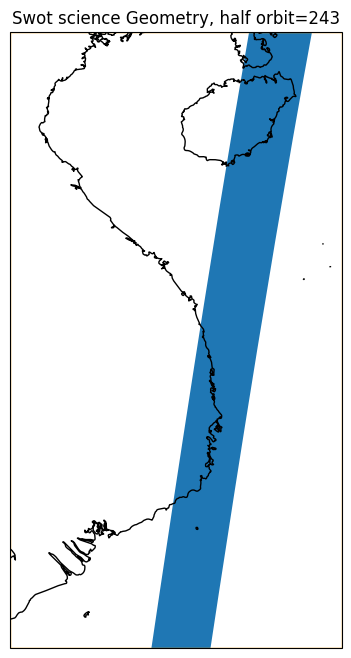

In [18]:
half_orbit_num = 243
plot_geometries(swath_geoms[swath_geoms['pass_number']==half_orbit_num], lon_range, lat_range, f"Swot {phase} Geometry, half orbit={half_orbit_num}", plot_extent)

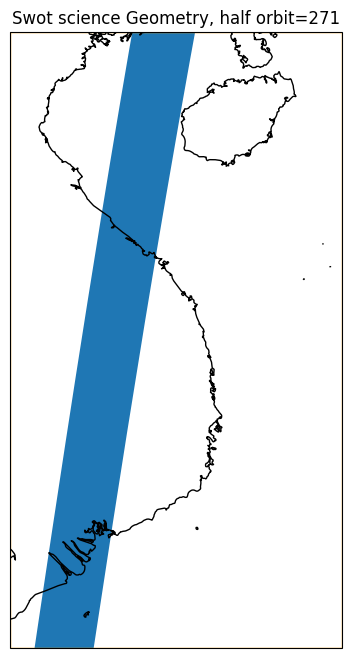

In [19]:
half_orbit_num = 271
plot_geometries(swath_geoms[swath_geoms['pass_number']==half_orbit_num], lon_range, lat_range, f"Swot {phase} Geometry, half orbit={half_orbit_num}", plot_extent)

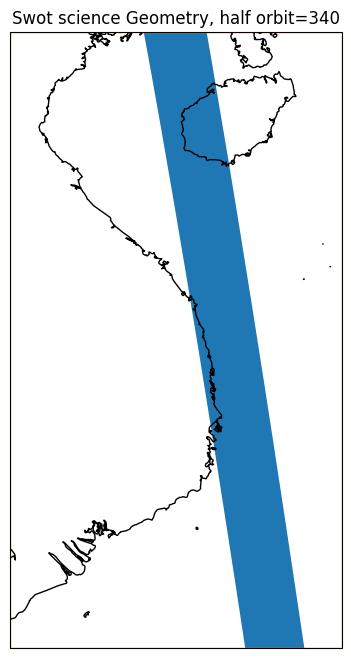

In [20]:
half_orbit_num = 340
plot_geometries(swath_geoms[swath_geoms['pass_number']==half_orbit_num], lon_range, lat_range, f"Swot {phase} Geometry, half orbit={half_orbit_num}", plot_extent)

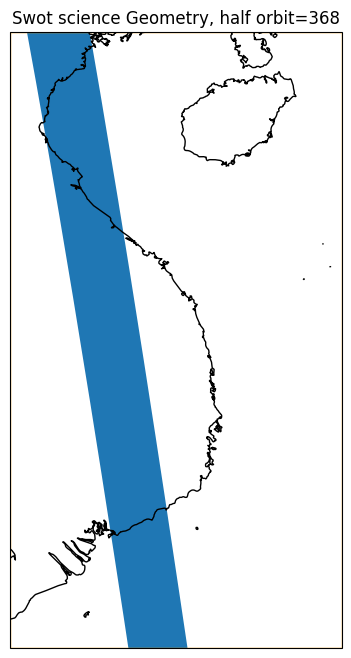

In [21]:
half_orbit_num = 368
plot_geometries(swath_geoms[swath_geoms['pass_number']==half_orbit_num], lon_range, lat_range, f"Swot {phase} Geometry, half orbit={half_orbit_num}", plot_extent)

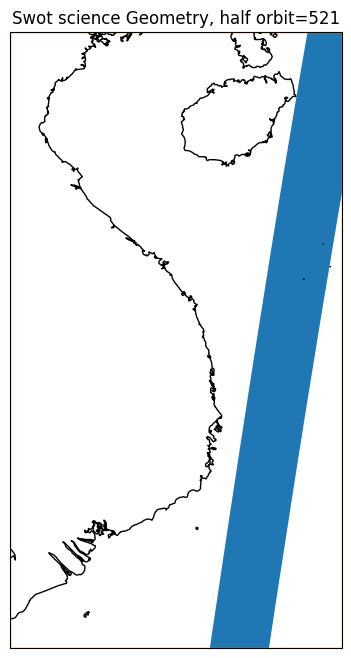

In [22]:
half_orbit_num = 521
plot_geometries(swath_geoms[swath_geoms['pass_number']==half_orbit_num], lon_range, lat_range, f"Swot {phase} Geometry, half orbit={half_orbit_num}", plot_extent)

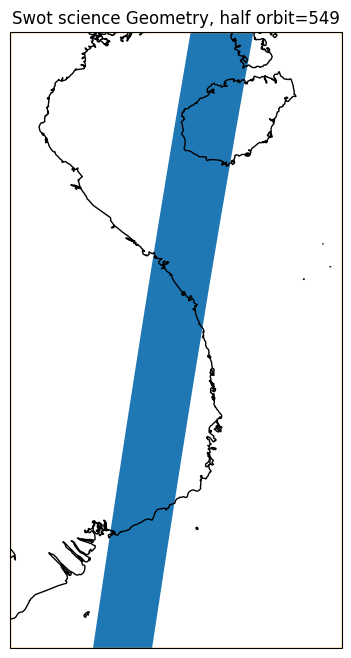

In [23]:
half_orbit_num = 549
plot_geometries(swath_geoms[swath_geoms['pass_number']==half_orbit_num], lon_range, lat_range, f"Swot {phase} Geometry, half orbit={half_orbit_num}", plot_extent)

---
## Next Steps

- Use the exported `swot_passes.csv` to filter SWOT data downloads by pass number.
- Selected passes of interest for the Lower Mekong region: **62, 243, 271, 340, 368, 521, 549**.
- These pass numbers can be used as query parameters when downloading SWOT L2 products from NASA PO.DAAC or Earthdata.